# Supplier Risk — rodada experimental 01

**Pergunta:** os dados permitem classificar a label fornecida `Risk_Level` melhor que a classe majoritária do TRAIN?

**Fronteira:** TRAIN ajusta; VALIDATION compara. **Nenhum arquivo de TEST é aberto.** Não há tuning, GridSearch, CV, ajuste de threshold, calibração, escolha definitiva ou exportação de modelos. Resultados são exclusivamente experimentais, incorporados a este notebook.

0 = menor risco; 1 = maior risco, conforme convenção do projeto. A origem da label não está comprovada. `predict_proba` estima pertencimento à classe 1, **não probabilidade real de falha futura**.

## Protocolo fixado antes da execução

- Baseline: `DummyClassifier(strategy="most_frequent")`, classe aprendida do TRAIN.
- Logistic Regression: imputador mediano → StandardScaler → LR, C=1, lbfgs, max_iter=1000, seed=42, sem ponderação de classes. O limite maior é uma precaução de convergência, não tuning.
- Random Forest: imputador mediano → RF, 100 árvores, seed=42, n_jobs=-1, demais parâmetros padrão. Mesma configuração em A/B/C/D.
- **Orçamento:** uma baseline + quatro ajustes de LR + quatro ajustes de RF = nove fits. Nenhuma busca adaptativa. Predições usam `predict()` padrão, sem corte customizado.
- A: dez features; B: sem índice geopolítico; C: sem contagem; D: sem ambas.
- Métrica principal: F1-macro. Secundárias: accuracy, balanced accuracy, precision/recall/F1 por classe, ROC-AUC, Average Precision e matriz de confusão [0,1].
- Incerteza descritiva: bootstrap pareado de predições VALIDATION, 2.000 reamostragens, seed=42, IC percentil de 95% para diferenças de F1-macro/balanced accuracy. Não refaz treinamento nem corrige comparações múltiplas. Não representa variabilidade entre seeds ou novas populações.

Reprodução: Python 3.14.3, ambiente isolado com `ml/supplier_risk/notebooks/requirements.txt`. Executar a partir da raiz ou de notebooks/. O kernel mantém modelos somente em memória e não grava datasets ou artefatos de produção.


In [1]:
import hashlib
import json
import platform
import warnings
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

get_ipython().run_line_magic("matplotlib", "inline")
assert platform.python_version() == "3.14.3", "Selecionar o kernel Python 3.14.3."
assert version("pandas") == "2.3.3" and version("scikit-learn") == "1.9.0"
ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "ml/supplier_risk/scripts/build_ml_dataset.py").is_file()), None,
)
assert ROOT is not None, "Executar na raiz do projeto ou em notebooks/."
ML_DIR = ROOT / "data/processed/supplier_risk/ml_ready"
INPUTS = {name: ML_DIR / f"{name}.parquet" for name in (
    "X_train", "X_validation", "y_train", "y_validation",
)}
METADATA_PATH = ML_DIR / "preprocessing_metadata.json"
FEATURES = [
    "financial_stability_score", "on_time_delivery_rate", "defect_rate",
    "geopolitical_risk_index", "lead_time_days", "alternative_suppliers_available",
    "contract_length_months", "environmental_compliance", "previous_disruptions",
    "supplier_record_count",
]
EXCLUSIONS = {
    "A": [], "B": ["geopolitical_risk_index"], "C": ["supplier_record_count"],
    "D": ["geopolitical_risk_index", "supplier_record_count"],
}
FEATURE_SETS = {key: [f for f in FEATURES if f not in excluded] for key, excluded in EXCLUSIONS.items()}
SEED = 42
BOOTSTRAP_REPS = 2000
LR_PARAMS = {"C": 1.0, "solver": "lbfgs", "max_iter": 1000, "random_state": SEED}
RF_PARAMS = {"n_estimators": 100, "random_state": SEED, "n_jobs": -1}

def make_pipeline(family):
    if family == "LR":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(**LR_PARAMS)),
        ])
    if family == "RF":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(**RF_PARAMS)),
        ])
    raise ValueError(f"Família não prevista: {family}")

def file_hash(path):
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest().upper()

def frame_hash(frame):
    return hashlib.sha256(pd.util.hash_pandas_object(frame, index=True).values.tobytes()).hexdigest()

pd.set_option("display.max_columns", 25)
pd.set_option("display.max_rows", 100)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"Baseline": "#888888", "LR": "#176b87", "RF": "#cc6633"}
print("Rodada 1.0 — geração UTC:", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version())
display(pd.Series({p: version(p) for p in (
    "pandas", "numpy", "pyarrow", "scikit-learn", "matplotlib", "nbformat", "nbclient",
)}, name="versão"))
for family in ["LR", "RF"]:
    print(family, make_pipeline(family).named_steps["model"].get_params())
display(pd.DataFrame([
    {"versão": k, "n_features": len(v), "features": ", ".join(v)}
    for k, v in FEATURE_SETS.items()
]))


Rodada 1.0 — geração UTC: 2026-09-17T01:03:50.921345+00:00
Python: 3.14.3


pandas           2.3.3
numpy            2.5.2
pyarrow         25.0.1
scikit-learn     1.9.0
matplotlib      3.11.2
nbformat        5.10.4
nbclient        0.10.4
Name: versão, dtype: object

LR {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
RF {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


,versão,n_features,features
0,A,10,"financial_stability_score, on_time_delivery_ra..."
1,B,9,"financial_stability_score, on_time_delivery_ra..."
2,C,9,"financial_stability_score, on_time_delivery_ra..."
3,D,8,"financial_stability_score, on_time_delivery_ra..."


## 1. Entradas, alinhamento e validações

São carregados **somente os quatro Parquets TRAIN/VALIDATION** solicitados. O metadata existente fornece o contrato e os SHA-256 das saídas; consultamos apenas campos necessários a TRAIN/VALIDATION, sem exibir ou usar estatísticas de TEST.

X/y não possuem IDs. A checagem combina índices posicionais, schemas, tamanhos e **hashes exatos de cada saída**, preservando a correspondência por supplier_id ordenado que o produtor validou. Igualdade de RangeIndex isoladamente não provaria alinhamento. A reconciliação/disjunção de IDs é a registrada pelo produtor; não é recalculada a partir de X/y sem identificadores.

**Imputação já realizada:** o ML-Ready original foi gerado com medianas aprendidas no TRAIN. O SimpleImputer obrigatório é novamente fitado somente no TRAIN dentro de cada pipeline, mas sua transformação é neutra nesta matriz sem nulos. Não há CV nesta rodada; uma CV futura deverá partir da base pré-imputação com transformadores internos a cada fold.


In [2]:
assert all(p.is_file() for p in INPUTS.values()) and METADATA_PATH.is_file()
original_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
contract = {
    "features": original_metadata["features_utilizadas"],
    "train_only": original_metadata["imputador_ajustado_somente_no_treino"],
    "scaling": original_metadata["scaling"],
    "encoding": original_metadata["encoding"],
    "ordering": original_metadata["ordenacao_linhas_X_y"],
    "overlap": original_metadata["reconciliacao_ids"]["overlap"]["train_validation"],
    "output_hashes": {
        name: original_metadata["hashes_saidas_sha256"][p.relative_to(ROOT).as_posix()]
        for name, p in INPUTS.items()
    },
    "producer_hash": original_metadata["hash_script_sha256"],
}
del original_metadata
assert contract["features"] == FEATURES and contract["train_only"] is True
assert contract["scaling"] is False and contract["encoding"] is False
assert contract["overlap"] == 0
assert contract["ordering"] == "supplier_id textual em ordem crescente dentro de cada split"
assert file_hash(ROOT / "ml/supplier_risk/scripts/build_ml_dataset.py") == contract["producer_hash"]
INPUT_HASHES = {name: file_hash(path) for name, path in INPUTS.items()}
assert INPUT_HASHES == contract["output_hashes"], "Saídas não correspondem ao metadata; interromper."
METADATA_HASH = file_hash(METADATA_PATH)
READ_LOG = []

def read_allowed(name):
    if name not in INPUTS:
        raise ValueError("Acesso fora da lista TRAIN/VALIDATION proibido nesta rodada.")
    READ_LOG.append(name)
    return pd.read_parquet(INPUTS[name], engine="pyarrow")

frames = {name: read_allowed(name) for name in INPUTS}
for split, expected_size in [("train", 16_894), ("validation", 3_539)]:
    x, y = frames[f"X_{split}"], frames[f"y_{split}"]
    assert x.shape == (expected_size, 10) and y.shape == (expected_size, 1)
    assert x.columns.tolist() == FEATURES and y.columns.tolist() == ["risk_level"]
    assert x.index.equals(pd.RangeIndex(expected_size)) and y.index.equals(x.index)
    assert x.index.name is None and y.index.name is None
    assert not x.columns.duplicated().any() and not y.columns.duplicated().any()
    assert all(
        pd.api.types.is_numeric_dtype(x[f])
        and not pd.api.types.is_bool_dtype(x[f])
        and not pd.api.types.is_complex_dtype(x[f]) for f in FEATURES
    )
    assert np.isfinite(x.to_numpy(dtype=float)).all(), f"{split}: nulo/infinito em X"
    assert y["risk_level"].notna().all() and set(y["risk_level"].unique()) == {0, 1}
FRAME_HASHES = {name: frame_hash(frame) for name, frame in frames.items()}
X_train, X_validation = frames["X_train"], frames["X_validation"]
y_train = frames["y_train"]["risk_level"]
y_validation = frames["y_validation"]["risk_level"]
target_rows = []
for split, target in [("TRAIN", y_train), ("VALIDATION", y_validation)]:
    for risk in [0, 1]:
        n = int(target.eq(risk).sum())
        target_rows.append({"conjunto": split, "classe": risk, "n": n, "percentual": n / len(target) * 100})
target_distribution = pd.DataFrame(target_rows)
display(target_distribution.round(4))
print("TRAIN:", X_train.shape, "| VALIDATION:", X_validation.shape)
print("Schemas, alinhamento por contrato/hash, ausência de IDs/target em X e finitude: OK.")
for name, digest in INPUT_HASHES.items():
    print(f"SHA-256 {name}: {digest}")
print("Arquivos Parquet lidos:", READ_LOG)


,conjunto,classe,n,percentual
0,TRAIN,0,5008,29.6437
1,TRAIN,1,11886,70.3563
2,VALIDATION,0,1110,31.3648
3,VALIDATION,1,2429,68.6352


TRAIN: (16894, 10) | VALIDATION: (3539, 10)
Schemas, alinhamento por contrato/hash, ausência de IDs/target em X e finitude: OK.
SHA-256 X_train: 21D7BAA5B62F4D0F42754DFE3BF36236C7EC9CFF610A5C8C5B3C1B651D1812B2
SHA-256 X_validation: 9C3C1E428A85FEA5F3E4D381956F553BC7518263145C800006E6731480EA0DE0
SHA-256 y_train: DECF5DCD969624BF89C69635EEB2E3C1C99F2589A9D7BE71E4E069C885587F43
SHA-256 y_validation: 1BD1B619C50E2B124679AE7C0ED9A9D14E00691132552EBBB95677303F319134
Arquivos Parquet lidos: ['X_train', 'X_validation', 'y_train', 'y_validation']


## 2. Avaliação comum

Todas as métricas abaixo usam exclusivamente **VALIDATION**, com os mesmos fornecedores. F1-macro inclui ambas as classes, com peso igual; precision/F1 sem predições de uma classe usam `zero_division=0`.
ROC-AUC e Average Precision usam score contínuo da classe 1; AP não é integração trapezoidal da curva PR. A baseline constante pode ter ROC-AUC 0,5 e AP igual à prevalência de classe 1: isso não significa capacidade de ordenar fornecedores.
Matrizes: linhas = classe real, colunas = predição, ordem [0,1].


In [3]:
def evaluate(target, prediction, probability):
    assert len(target) == len(prediction) == len(probability)
    assert np.isfinite(probability).all() and ((probability >= 0) & (probability <= 1)).all()
    assert set(np.unique(prediction)).issubset({0, 1})
    precision, recall, f1, support = precision_recall_fscore_support(
        target, prediction, labels=[0, 1], zero_division=0,
    )
    cm = confusion_matrix(target, prediction, labels=[0, 1])
    metrics = {
        "accuracy": accuracy_score(target, prediction),
        "balanced_accuracy": balanced_accuracy_score(target, prediction),
        "f1_macro": f1_score(target, prediction, labels=[0, 1], average="macro", zero_division=0),
        "roc_auc": roc_auc_score(target, probability) if target.nunique() == 2 else np.nan,
        "average_precision": average_precision_score(target, probability),
    }
    for risk in [0, 1]:
        metrics.update({
            f"precision_{risk}": precision[risk], f"recall_{risk}": recall[risk],
            f"f1_{risk}": f1[risk], f"support_{risk}": int(support[risk]),
        })
    for label, value in zip(["tn", "fp", "fn", "tp"], cm.ravel(), strict=True):
        metrics[label] = int(value)
    return metrics

results_rows = []
predictions = {}
fitted_models = {}
fit_audit_rows = []
fit_warnings = {}
MAJORITY = int(y_train.value_counts().idxmax())
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_prediction = baseline.predict(X_validation)
assert np.all(baseline_prediction == MAJORITY)
baseline_probability = baseline.predict_proba(X_validation)[:, list(baseline.classes_).index(1)]
predictions["Baseline"] = {"labels": baseline_prediction, "probability": baseline_probability}
results_rows.append({
    "id": "Baseline", "family": "Baseline", "variant": "-", "n_features": 0,
    **evaluate(y_validation, baseline_prediction, baseline_probability),
})
print("Classe majoritária aprendida do TRAIN:", MAJORITY)
print("Ponto mínimo de comparação; nenhuma escolha pela distribuição de VALIDATION.")
display(pd.DataFrame(results_rows).set_index("id").round(4))


Classe majoritária aprendida do TRAIN: 1
Ponto mínimo de comparação; nenhuma escolha pela distribuição de VALIDATION.


,family,variant,n_features,accuracy,balanced_accuracy,f1_macro,roc_auc,average_precision,precision_0,recall_0,f1_0,support_0,precision_1,recall_1,f1_1,support_1,tn,fp,fn,tp
id,,,,,,,,,,,,,,,,,,,,
Baseline,Baseline,-,0,0.6864,0.5,0.407,0.5,0.6864,0.0,0.0,0.0,1110,0.6864,1.0,0.814,2429,0,1110,0,2429


## 3. Ajustes fixos de LR e RF — A/B/C/D

Cada variante é treinada do zero **somente em TRAIN**, com a mesma configuração da família. VALIDATION recebe apenas `predict`/`predict_proba`; não há fit em VALIDATION. A ablação altera a seleção de colunas em memória, nunca os Parquets.
Avisos de convergência interrompem a execução em vez de ocultar ajuste incompleto. As estatísticas dos transformadores são conferidas contra TRAIN e permanecem iguais após a avaliação.


In [4]:
for family in ["LR", "RF"]:
    for variant, selected in FEATURE_SETS.items():
        model_id = f"{family}_{variant}"
        train_part, validation_part = X_train[selected], X_validation[selected]
        pipeline = make_pipeline(family)
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter("always")
            pipeline.fit(train_part, y_train)
        fit_warnings[model_id] = [str(w.message) for w in captured]
        if any(issubclass(w.category, ConvergenceWarning) for w in captured):
            raise RuntimeError(f"{model_id}: falha de convergência; não comparar como fit concluído.")
        imputer = pipeline.named_steps["imputer"]
        np.testing.assert_allclose(imputer.statistics_, train_part.median().to_numpy(), rtol=1e-12)
        np.testing.assert_array_equal(imputer.transform(train_part), train_part.to_numpy())
        np.testing.assert_array_equal(imputer.transform(validation_part), validation_part.to_numpy())
        imputer_state = imputer.statistics_.copy()
        if family == "LR":
            scaler = pipeline.named_steps["scaler"]
            assert np.all(np.asarray(scaler.n_samples_seen_) == len(X_train))
            np.testing.assert_allclose(scaler.mean_, train_part.mean().to_numpy(), rtol=1e-12)
            scaler_state = (scaler.mean_.copy(), scaler.scale_.copy())
        assert list(pipeline.classes_) == [0, 1]
        labels = pipeline.predict(validation_part)
        probability = pipeline.predict_proba(validation_part)[:, 1]
        np.testing.assert_array_equal(imputer.statistics_, imputer_state)
        if family == "LR":
            np.testing.assert_array_equal(scaler.mean_, scaler_state[0])
            np.testing.assert_array_equal(scaler.scale_, scaler_state[1])
        fitted_models[model_id] = pipeline
        predictions[model_id] = {"labels": labels, "probability": probability}
        results_rows.append({
            "id": model_id, "family": family, "variant": variant, "n_features": len(selected),
            **evaluate(y_validation, labels, probability),
        })
        fit_audit_rows.append({
            "id": model_id, "linhas_fit": len(train_part), "features": len(selected),
            "imputer_train_only": True, "scaler_train_only": family == "LR",
            "transformadores_inalterados_apos_validation": True,
            "avisos": len(captured),
        })
assert len(fitted_models) == 8 and len(results_rows) == 9
results = pd.DataFrame(results_rows).set_index("id")
fit_audit = pd.DataFrame(fit_audit_rows).set_index("id")
display(fit_audit)
print("Avisos de fit:", fit_warnings)
print("Nove fits concluídos: uma baseline, quatro LR e quatro RF; nenhum ajuste adicional.")


,linhas_fit,features,imputer_train_only,scaler_train_only,transformadores_inalterados_apos_validation,avisos
id,,,,,,
LR_A,16894,10,True,True,True,0
LR_B,16894,9,True,True,True,0
LR_C,16894,9,True,True,True,0
LR_D,16894,8,True,True,True,0
RF_A,16894,10,True,False,True,0
RF_B,16894,9,True,False,True,0
RF_C,16894,9,True,False,True,0
RF_D,16894,8,True,False,True,0


Avisos de fit: {'LR_A': [], 'LR_B': [], 'LR_C': [], 'LR_D': [], 'RF_A': [], 'RF_B': [], 'RF_C': [], 'RF_D': []}
Nove fits concluídos: uma baseline, quatro LR e quatro RF; nenhum ajuste adicional.


## 4. Comparação inicial — conjunto A

Ordenação por F1-macro é descritiva, **não escolha definitiva**. Avaliar recall/F1 das duas classes e comparar com a estratégia que prevê somente a maioria.
A tabela completa inclui métricas por classe e contagens da matriz de confusão.


,accuracy,balanced_accuracy,f1_macro,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,roc_auc,average_precision
id,,,,,,,,,,,
LR_A,0.94010,0.92432,0.92955,0.92358,0.88198,0.90230,0.94716,0.96665,0.95681,0.98765,0.99429
RF_A,0.92879,0.90630,0.91538,0.92059,0.84595,0.88169,0.93212,0.96665,0.94907,0.97580,0.98792
Baseline,0.68635,0.50000,0.40700,0.00000,0.00000,0.00000,0.68635,1.00000,0.81401,0.50000,0.68635


,tn,fp,fn,tp,support_0,support_1
id,,,,,,
LR_A,979,131,81,2348,1110,2429
RF_A,939,171,81,2348,1110,2429
Baseline,0,1110,0,2429,1110,2429


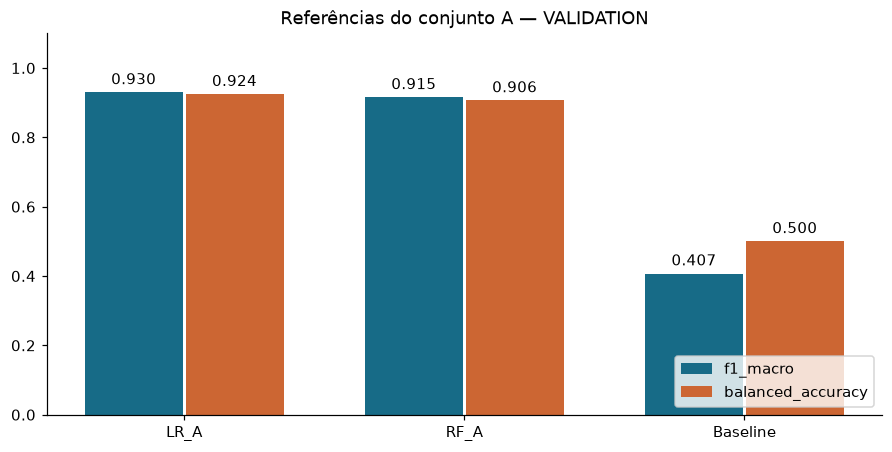

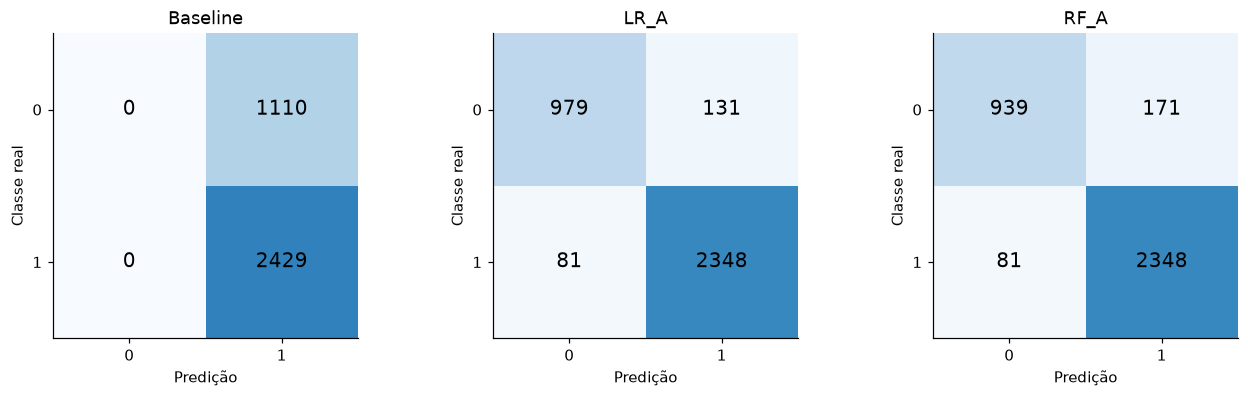

In [5]:
METRICS = [
    "accuracy", "balanced_accuracy", "f1_macro", "precision_0", "recall_0", "f1_0",
    "precision_1", "recall_1", "f1_1", "roc_auc", "average_precision",
]
core_results = results.loc[["Baseline", "LR_A", "RF_A"]].sort_values("f1_macro", ascending=False)
display(core_results[METRICS].round(5))
display(core_results[["tn", "fp", "fn", "tp", "support_0", "support_1"]])
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
positions = np.arange(len(core_results))
for offset, metric, color in [(-.18, "f1_macro", "#176b87"), (.18, "balanced_accuracy", "#cc6633")]:
    bars = ax.bar(positions + offset, core_results[metric], width=.35, label=metric, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticks(positions, core_results.index)
ax.set(ylim=(0, 1.1), title="Referências do conjunto A — VALIDATION")
ax.legend(loc="lower right")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")
for ax, model_id in zip(axes, ["Baseline", "LR_A", "RF_A"], strict=True):
    cm = confusion_matrix(y_validation, predictions[model_id]["labels"], labels=[0, 1])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=len(y_validation))
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=13)
    ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="Predição", ylabel="Classe real", title=model_id)
plt.show()


## 5. Ablações — somente comparação em VALIDATION

A/B/C/D usam exatamente os mesmos fornecedores de TRAIN/VALIDATION. Cada modelo foi fitado apenas em TRAIN. Nenhuma versão final será escolhida.
As features de cada versão estão registradas na configuração inicial; abaixo ficam métricas de todas as oito configurações, incluindo ambas as classes.


,family,variant,n_features,accuracy,balanced_accuracy,f1_macro,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,roc_auc,average_precision
id,,,,,,,,,,,,,,
LR_A,LR,A,10,0.94010,0.92432,0.92955,0.92358,0.88198,0.90230,0.94716,0.96665,0.95681,0.98765,0.99429
LR_C,LR,C,9,0.94010,0.92432,0.92955,0.92358,0.88198,0.90230,0.94716,0.96665,0.95681,0.98766,0.99429
RF_C,RF,C,9,0.92936,0.90671,0.91601,0.92240,0.84595,0.88252,0.93217,0.96748,0.94949,0.97646,0.98829
RF_A,RF,A,10,0.92879,0.90630,0.91538,0.92059,0.84595,0.88169,0.93212,0.96665,0.94907,0.97580,0.98792
LR_D,LR,D,8,0.82566,0.77417,0.78685,0.76823,0.63604,0.69591,0.84580,0.91231,0.87780,0.89858,0.95062
LR_B,LR,B,9,0.82537,0.77397,0.78657,0.76739,0.63604,0.69557,0.84574,0.91190,0.87758,0.89852,0.95059
RF_D,RF,D,8,0.82340,0.76666,0.78148,0.77588,0.61441,0.68577,0.83910,0.91890,0.87719,0.88640,0.93894
RF_B,RF,B,9,0.82198,0.76489,0.77966,0.77335,0.61171,0.68310,0.83803,0.91807,0.87623,0.88567,0.93962


,tn,fp,fn,tp
id,,,,
LR_A,979,131,81,2348
LR_B,706,404,214,2215
LR_C,979,131,81,2348
LR_D,706,404,213,2216
RF_A,939,171,81,2348
RF_B,679,431,199,2230
RF_C,939,171,79,2350
RF_D,682,428,197,2232


,family,variant,f1_macro,balanced_accuracy,delta_f1_macro_vs_A,delta_balanced_accuracy_vs_A
id,,,,,,
LR_A,LR,A,0.92955,0.92432,0.00000,0.00000
LR_B,LR,B,0.78657,0.77397,-0.14298,-0.15035
LR_C,LR,C,0.92955,0.92432,0.00000,0.00000
LR_D,LR,D,0.78685,0.77417,-0.14270,-0.15014
RF_A,RF,A,0.91538,0.90630,0.00000,0.00000
RF_B,RF,B,0.77966,0.76489,-0.13572,-0.14141
RF_C,RF,C,0.91601,0.90671,0.00063,0.00041
RF_D,RF,D,0.78148,0.76666,-0.13390,-0.13964


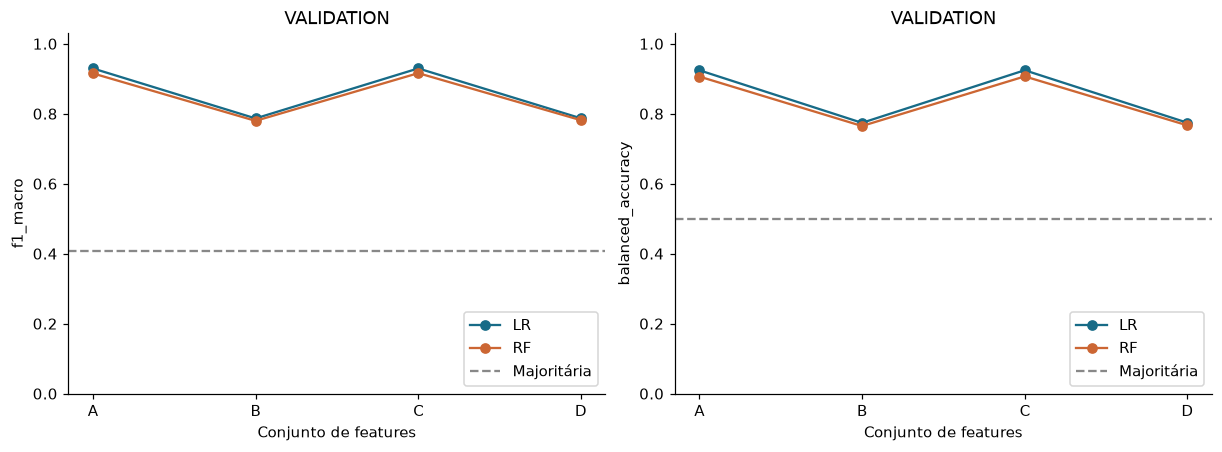

In [6]:
ablation_results = results.loc[results["family"].isin(["LR", "RF"])].copy()
display(ablation_results[["family", "variant", "n_features", *METRICS]].sort_values("f1_macro", ascending=False).round(5))
display(ablation_results[["tn", "fp", "fn", "tp"]])
ablation_deltas = ablation_results[["family", "variant", "f1_macro", "balanced_accuracy"]].copy()
for family in ["LR", "RF"]:
    mask = ablation_deltas["family"].eq(family)
    for metric in ["f1_macro", "balanced_accuracy"]:
        ablation_deltas.loc[mask, f"delta_{metric}_vs_A"] = (
            ablation_deltas.loc[mask, metric] - results.at[f"{family}_A", metric]
        )
display(ablation_deltas.round(5))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metric in zip(axes, ["f1_macro", "balanced_accuracy"], strict=True):
    for family in ["LR", "RF"]:
        values = [results.at[f"{family}_{variant}", metric] for variant in FEATURE_SETS]
        ax.plot(list(FEATURE_SETS), values, marker="o", label=family, color=COLORS[family])
    ax.axhline(results.at["Baseline", metric], color=COLORS["Baseline"], linestyle="--", label="Majoritária")
    ax.set(ylim=(0, 1.03), xlabel="Conjunto de features", ylabel=metric, title="VALIDATION")
    ax.legend(loc="lower right")
plt.show()


## 6. Incerteza pareada — sem novos fits

Reamostrar as mesmas linhas de VALIDATION para todas as predições mantém a comparação pareada. São 2.000 sorteios com reposição, seed 42; sorteios sem ambas as classes seriam descartados e contabilizados.
Comparações pré-definidas: oito configurações contra a majoritária; RF_A − LR_A; B/C/D − A em cada família; D − B para o efeito da contagem sem o índice geopolítico.
ICs são percentis marginais, condicionais aos modelos já ajustados: **não** corrigem múltiplas comparações, seleção repetida na validação ou incerteza do treinamento. São evidência exploratória, não conclusão definitiva ou validação empresarial.


In [7]:
MODEL_IDS = results.index.tolist()
prediction_matrix = np.column_stack([predictions[k]["labels"] for k in MODEL_IDS]).astype("int64")
truth = y_validation.to_numpy(dtype="int64")
encoded = 2 * truth[:, None] + prediction_matrix
offsets = 4 * np.arange(len(MODEL_IDS))

def scores_from_counts(counts):
    tn, fp, fn, tp = counts.T.astype(float)
    f1_0 = np.divide(2 * tn, 2 * tn + fp + fn, out=np.zeros_like(tn), where=(2 * tn + fp + fn) != 0)
    f1_1 = np.divide(2 * tp, 2 * tp + fp + fn, out=np.zeros_like(tp), where=(2 * tp + fp + fn) != 0)
    return np.column_stack(((f1_0 + f1_1) / 2, (tn / (tn + fp) + tp / (tp + fn)) / 2))

observed_counts = np.bincount((encoded + offsets).ravel(), minlength=4 * len(MODEL_IDS)).reshape(-1, 4)
np.testing.assert_allclose(
    scores_from_counts(observed_counts), results[["f1_macro", "balanced_accuracy"]].to_numpy(),
    rtol=1e-12, atol=1e-12,
)
rng = np.random.default_rng(SEED)
bootstrap_scores = np.full((BOOTSTRAP_REPS, len(MODEL_IDS), 2), np.nan)
skipped = 0
for draw in range(BOOTSTRAP_REPS):
    indices = rng.integers(0, len(truth), size=len(truth))
    if np.unique(truth[indices]).size != 2:
        skipped += 1
        continue
    counts = np.bincount(
        (encoded[indices] + offsets).ravel(), minlength=4 * len(MODEL_IDS),
    ).reshape(-1, 4)
    bootstrap_scores[draw] = scores_from_counts(counts)
assert skipped < BOOTSTRAP_REPS
COMPARISONS = (
    [(key, "Baseline") for key in MODEL_IDS if key != "Baseline"]
    + [("RF_A", "LR_A")]
    + [(f"{family}_{variant}", f"{family}_A") for family in ["LR", "RF"] for variant in ["B", "C", "D"]]
    + [(f"{family}_D", f"{family}_B") for family in ["LR", "RF"]]
)
ci_rows = []
for candidate, reference in COMPARISONS:
    difference = bootstrap_scores[:, MODEL_IDS.index(candidate)] - bootstrap_scores[:, MODEL_IDS.index(reference)]
    for column, metric in enumerate(["f1_macro", "balanced_accuracy"]):
        lower, upper = np.nanpercentile(difference[:, column], [2.5, 97.5])
        ci_rows.append({
            "candidate": candidate, "reference": reference, "metric": metric,
            "delta": results.at[candidate, metric] - results.at[reference, metric],
            "lower_95": lower, "upper_95": upper,
        })
confidence_intervals = pd.DataFrame(ci_rows)
display(confidence_intervals.round(5))
print("Reamostragens válidas:", BOOTSTRAP_REPS - skipped, "| sem ambas as classes:", skipped)
ci_lookup = confidence_intervals.set_index(["candidate", "reference", "metric"])
utility_rows = []
for model_id in MODEL_IDS[1:]:
    f1_ci = ci_lookup.loc[(model_id, "Baseline", "f1_macro")]
    ba_ci = ci_lookup.loc[(model_id, "Baseline", "balanced_accuracy")]
    both_classes = bool((results.loc[model_id, ["recall_0", "recall_1", "f1_0", "f1_1"]] > 0).all())
    utility_rows.append({
        "modelo": model_id, "reconhece_ambas_classes": both_classes,
        "IC_delta_F1_acima_zero": bool(f1_ci["lower_95"] > 0),
        "IC_delta_BA_acima_zero": bool(ba_ci["lower_95"] > 0),
        "evidencia_contra_majoritaria": both_classes and f1_ci["lower_95"] > 0 and ba_ci["lower_95"] > 0,
    })
utility_evidence = pd.DataFrame(utility_rows)
display(utility_evidence)
print("Elegibilidade experimental contra a referência trivial não define modelo final.")


,candidate,reference,metric,delta,lower_95,upper_95
0,LR_A,Baseline,f1_macro,0.52255,0.51102,0.53248
1,LR_A,Baseline,balanced_accuracy,0.42432,0.41395,0.43389
2,LR_B,Baseline,f1_macro,0.37957,0.36273,0.39495
3,LR_B,Baseline,balanced_accuracy,0.27397,0.25824,0.28844
4,LR_C,Baseline,f1_macro,0.52255,0.51102,0.53248
5,LR_C,Baseline,balanced_accuracy,0.42432,0.41395,0.43389
6,LR_D,Baseline,f1_macro,0.37985,0.36314,0.39523
7,LR_D,Baseline,balanced_accuracy,0.27417,0.25860,0.28885
8,RF_A,Baseline,f1_macro,0.50838,0.49605,0.51987
9,RF_A,Baseline,balanced_accuracy,0.40630,0.39430,0.41728


Reamostragens válidas: 2000 | sem ambas as classes: 0


,modelo,reconhece_ambas_classes,IC_delta_F1_acima_zero,IC_delta_BA_acima_zero,evidencia_contra_majoritaria
0,LR_A,True,True,True,True
1,LR_B,True,True,True,True
2,LR_C,True,True,True,True
3,LR_D,True,True,True,True
4,RF_A,True,True,True,True
5,RF_B,True,True,True,True
6,RF_C,True,True,True,True
7,RF_D,True,True,True,True


Elegibilidade experimental contra a referência trivial não define modelo final.


## 7. Features — evidência exploratória dos modelos A

Coeficientes LR correspondem a uma unidade de desvio padrão do TRAIN, condicionados às demais features; sinal positivo aumenta o log-odds estimado da classe 1. Magnitude não é causalidade.
Importância RF é a redução média de impureza (MDI) calculada no treino. Pode favorecer variáveis de alta cardinalidade e não demonstra valor incremental fora da amostra. As ablações oferecem uma verificação complementar limitada.
Relacionar os resultados com a EDA, que encontrou associação descritiva da label com estabilidade financeira e índice geopolítico. A procedência da label/índice segue desconhecida.


,lr_coefficient_standardized,rf_importance_mdi,abs_lr_coefficient
feature,,,
financial_stability_score,-5.62404,0.38701,5.62404
geopolitical_risk_index,4.20136,0.19007,4.20136
alternative_suppliers_available,-2.43159,0.07753,2.43159
previous_disruptions,1.90549,0.04477,1.90549
environmental_compliance,-1.82045,0.08989,1.82045
contract_length_months,1.46598,0.06449,1.46598
on_time_delivery_rate,-0.77630,0.05555,0.77630
lead_time_days,0.50473,0.04314,0.50473
defect_rate,0.10179,0.04566,0.10179


Intercepto LR A: 3.526334292073002


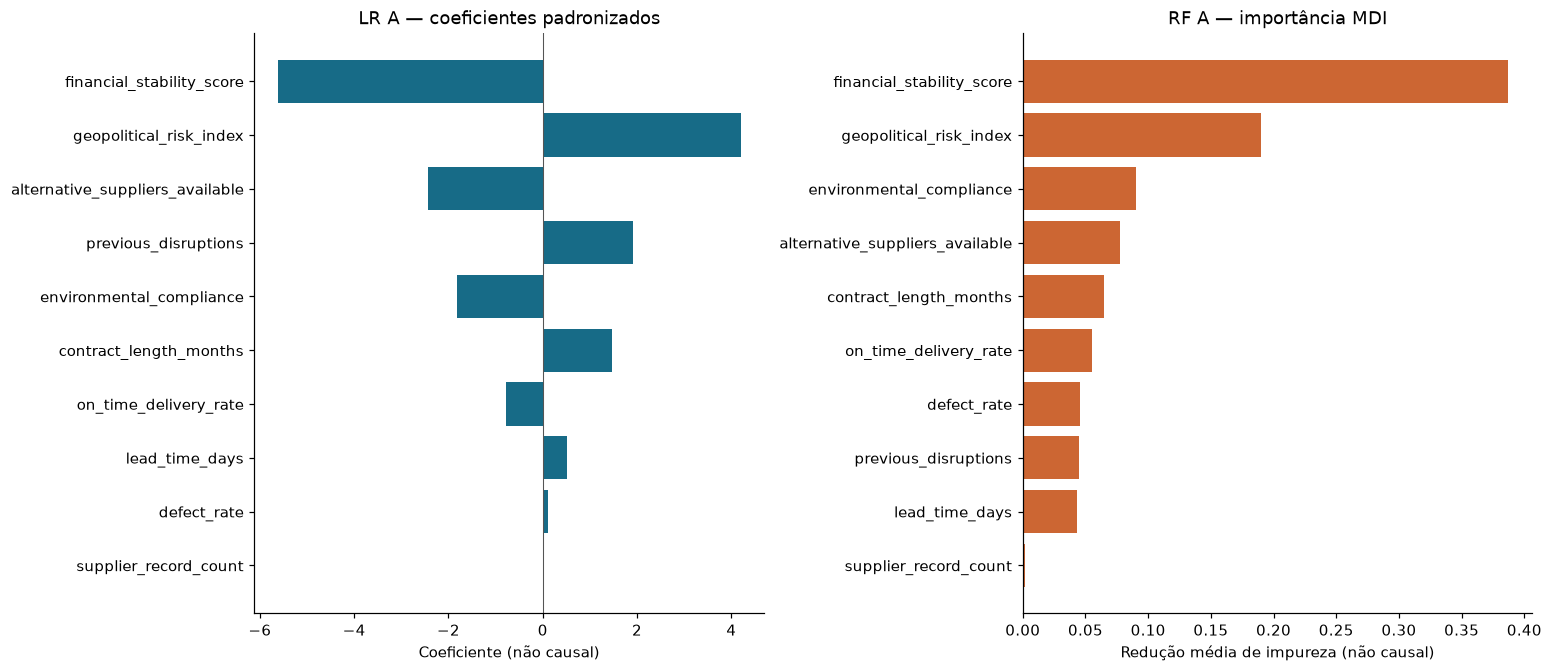

In [8]:
lr_estimator = fitted_models["LR_A"].named_steps["model"]
rf_estimator = fitted_models["RF_A"].named_steps["model"]
assert list(lr_estimator.classes_) == [0, 1]
feature_evidence = pd.DataFrame({
    "feature": FEATURES, "lr_coefficient_standardized": lr_estimator.coef_[0],
    "rf_importance_mdi": rf_estimator.feature_importances_,
}).set_index("feature")
feature_evidence["abs_lr_coefficient"] = feature_evidence["lr_coefficient_standardized"].abs()
display(feature_evidence.sort_values("abs_lr_coefficient", ascending=False).round(5))
print("Intercepto LR A:", float(lr_estimator.intercept_[0]))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
lr_order = feature_evidence.sort_values("abs_lr_coefficient")
rf_order = feature_evidence.sort_values("rf_importance_mdi")
axes[0].barh(lr_order.index, lr_order["lr_coefficient_standardized"], color=COLORS["LR"])
axes[0].axvline(0, color="#555555", linewidth=.7)
axes[0].set(title="LR A — coeficientes padronizados", xlabel="Coeficiente (não causal)")
axes[1].barh(rf_order.index, rf_order["rf_importance_mdi"], color=COLORS["RF"])
axes[1].set(title="RF A — importância MDI", xlabel="Redução média de impureza (não causal)")
plt.show()


## 8. Conclusões experimentais

Respostas abaixo referem-se apenas às configurações fixas e à VALIDATION desta rodada. Nenhuma afirmação de modelo pronto, algoritmo definitivo ou previsão real de falhas.
Uma diferença cujo IC cruza zero é inconclusiva nesta análise pareada; mesmo quando o IC não cruza zero, permanece a limitação de comparações múltiplas e de uma única divisão/seed.


In [9]:
def describe_difference(candidate, reference, metric="f1_macro"):
    row = ci_lookup.loc[(candidate, reference, metric)]
    if row["lower_95"] > 0:
        direction = "ganho no intervalo pareado"
    elif row["upper_95"] < 0:
        direction = "queda no intervalo pareado"
    else:
        direction = "diferença inconclusiva no intervalo pareado"
    return (
        f"{candidate} - {reference}: delta {metric}={row['delta']:+.5f}, "
        f"IC95% [{row['lower_95']:+.5f}, {row['upper_95']:+.5f}]; {direction}."
    )

print("1. Logistic Regression supera a baseline?")
print(describe_difference("LR_A", "Baseline"))
print(describe_difference("LR_A", "Baseline", "balanced_accuracy"))
print("\n2. Random Forest supera Logistic Regression?")
print(describe_difference("RF_A", "LR_A"))
print("\n3. As duas classes são reconhecidas?")
display(results.loc[["Baseline", "LR_A", "RF_A"], ["recall_0", "f1_0", "recall_1", "f1_1"]].round(5))
print("\n4. Efeito da remoção do índice geopolítico:")
for family in ["LR", "RF"]:
    print(describe_difference(f"{family}_B", f"{family}_A"))
print("\n5. Efeito de remover supplier_record_count:")
for family in ["LR", "RF"]:
    print(describe_difference(f"{family}_C", f"{family}_A"))
    print(describe_difference(f"{family}_D", f"{family}_B"))
print("\n6. Possíveis proxies:")
print("Relacionar magnitudes e ablações com a EDA. Associação não prova a regra original da label.")
print("Índice geopolítico continua provisório; contagem não representa histórico temporal.")
print("predict_proba estima pertencimento à classe 1; não foi avaliada calibração.")
print("Sem TEST, tuning, threshold ajustado ou escolha definitiva.")


1. Logistic Regression supera a baseline?
LR_A - Baseline: delta f1_macro=+0.52255, IC95% [+0.51102, +0.53248]; ganho no intervalo pareado.
LR_A - Baseline: delta balanced_accuracy=+0.42432, IC95% [+0.41395, +0.43389]; ganho no intervalo pareado.

2. Random Forest supera Logistic Regression?
RF_A - LR_A: delta f1_macro=-0.01417, IC95% [-0.02242, -0.00617]; queda no intervalo pareado.

3. As duas classes são reconhecidas?


,recall_0,f1_0,recall_1,f1_1
id,,,,
Baseline,0.00000,0.00000,1.00000,0.81401
LR_A,0.88198,0.90230,0.96665,0.95681
RF_A,0.84595,0.88169,0.96665,0.94907



4. Efeito da remoção do índice geopolítico:
LR_B - LR_A: delta f1_macro=-0.14298, IC95% [-0.15856, -0.12742]; queda no intervalo pareado.
RF_B - RF_A: delta f1_macro=-0.13572, IC95% [-0.15123, -0.12050]; queda no intervalo pareado.

5. Efeito de remover supplier_record_count:
LR_C - LR_A: delta f1_macro=+0.00000, IC95% [+0.00000, +0.00000]; diferença inconclusiva no intervalo pareado.
LR_D - LR_B: delta f1_macro=+0.00028, IC95% [-0.00057, +0.00114]; diferença inconclusiva no intervalo pareado.
RF_C - RF_A: delta f1_macro=+0.00063, IC95% [-0.00482, +0.00617]; diferença inconclusiva no intervalo pareado.
RF_D - RF_B: delta f1_macro=+0.00182, IC95% [-0.00584, +0.00968]; diferença inconclusiva no intervalo pareado.

6. Possíveis proxies:
Relacionar magnitudes e ablações com a EDA. Associação não prova a regra original da label.
Índice geopolítico continua provisório; contagem não representa histórico temporal.
predict_proba estima pertencimento à classe 1; não foi avaliada calibração.
Sem

## 9. Integridade e limites

Nenhum objeto ajustado é serializado. Modelos ficam apenas em memória durante a execução; tabelas e gráficos no notebook são resultados experimentais.
A auditoria abaixo confere hashes dos quatro arquivos usados e do metadata, além de detectar alterações nos DataFrames. Não abre TEST nem regrava arquivos de dados. O relatório externo documenta os resultados e os próximos passos sem autorizar teste final nesta etapa.


In [10]:
assert READ_LOG == ["X_train", "X_validation", "y_train", "y_validation"]
assert {name: file_hash(path) for name, path in INPUTS.items()} == INPUT_HASHES
assert file_hash(METADATA_PATH) == METADATA_HASH
assert {name: frame_hash(frame) for name, frame in frames.items()} == FRAME_HASHES
assert len(fitted_models) == 8 and len(results) == 9
assert results[METRICS].notna().all().all()
assert not any(fit_warnings.values()), "Há avisos de fit que precisam ser explicitamente revisados."
print("Entradas e DataFrames preservados. Apenas TRAIN/VALIDATION lidos.")
print("Nove fits experimentais; zero artefatos de produção; nenhum arquivo de TEST aberto.")


Entradas e DataFrames preservados. Apenas TRAIN/VALIDATION lidos.
Nove fits experimentais; zero artefatos de produção; nenhum arquivo de TEST aberto.
